# ML Models Training for IMDb Analysis

This notebook contains training pipelines for 6 machine learning models:

## Regression Models:
1. Season Rating Difference Prediction
2. Genre Duration vs Rating Prediction
3. Rising Star Score Prediction

## Classification Models:
1. Sophomore Slump Classification
2. Hook Shows Classification
3. Underrated Genre Combos Classification

In [2]:
from pyspark.sql import SparkSession
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StringIndexer, OneHotEncoder, StandardScaler
from pyspark.ml.regression import LinearRegression, RandomForestRegressor, GBTRegressor
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, GBTClassifier
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator, TrainValidationSplit
from pyspark.ml.evaluation import RegressionEvaluator, BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from utils.eval import evaluate_regression_models, evaluate_classification_models, plot_model_comparison
from utils.reader import read_data
from analysis import (
    season_rating_diff,
    genre_duration_rating_analysis,
    rising_stars,
    sophomore_slump,
    hook_shows,
    underrated_genre_combos
)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [3]:
# Initialize Spark Session
spark = SparkSession.builder \
    .appName("IMDb-ML-Training") \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "8g") \
    .getOrCreate()

print(f"Spark version: {spark.version}")
print("Spark session created successfully!")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/03 11:00:30 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 4.0.1
Spark session created successfully!


In [4]:
# Load data
print("Loading IMDb datasets...")
dataframes = read_data(spark)
print("\nDatasets loaded:")
for name, df in dataframes.items():
    print(f"  - {name}: {df.count():,} rows")

Loading IMDb datasets...

Datasets loaded:


  - name.basics: 14,861,451 rows


  - title.akas: 53,898,347 rows


  - title.basics: 12,048,919 rows


  - title.crew: 12,048,919 rows
  - title.episode: 9,285,221 rows


  - title.principals: 95,709,663 rows
  - title.ratings: 1,634,695 rows


## 1. Regression Model: Season Rating Difference Prediction

**Business Question:** Can we predict the rating difference between consecutive seasons?

**Target Variable:** `rating_diff` (continuous)

**Features:** `seasonNumber`, `prev_season_rating`, genre features, region

Preparing Season Rating Difference data...

BUSINESS QUESTION: Season rating dynamics for series with 3+ seasons

Series with highest rating growth between seasons:


+---------------------------------------+------------+-----------------+------------------+-----------+
|primaryTitle                           |seasonNumber|season_avg_rating|prev_season_rating|rating_diff|
+---------------------------------------+------------+-----------------+------------------+-----------+
|Come Dine with Me                      |37          |9.8              |1.83              |7.98       |
|The Merv Griffin Show                  |22          |9.2              |1.3               |7.9        |
|The Rick Mercer Report                 |6           |9.5              |2.0               |7.5        |
|SexTV                                  |7           |8.5              |1.15              |7.35       |
|The Talk                               |8           |8.1              |1.0               |7.1        |
|To Tell the Truth                      |11          |8.5              |1.7               |6.8        |
|Dinah!                                 |3           |9.55      

+------------------------+------------+-----------------+------------------+-----------+
|primaryTitle            |seasonNumber|season_avg_rating|prev_season_rating|rating_diff|
+------------------------+------------+-----------------+------------------+-----------+
|The Doctors             |6           |1.0              |10.0              |-9.0       |
|The David Frost Show    |4           |1.2              |9.7               |-8.5       |
|Loose Women             |21          |1.0              |9.3               |-8.3       |
|SportsCenter            |39          |1.6              |9.6               |-8.0       |
|The Playboy Morning Show|7           |1.7              |9.4               |-7.7       |
|Live with Kelly and Mark|29          |1.0              |8.7               |-7.7       |
|Pinoy Big Brother       |11          |1.0              |8.5               |-7.5       |
|Premier Boxing Champions|10          |1.0              |8.2               |-7.2       |
|Entertainment Tonigh

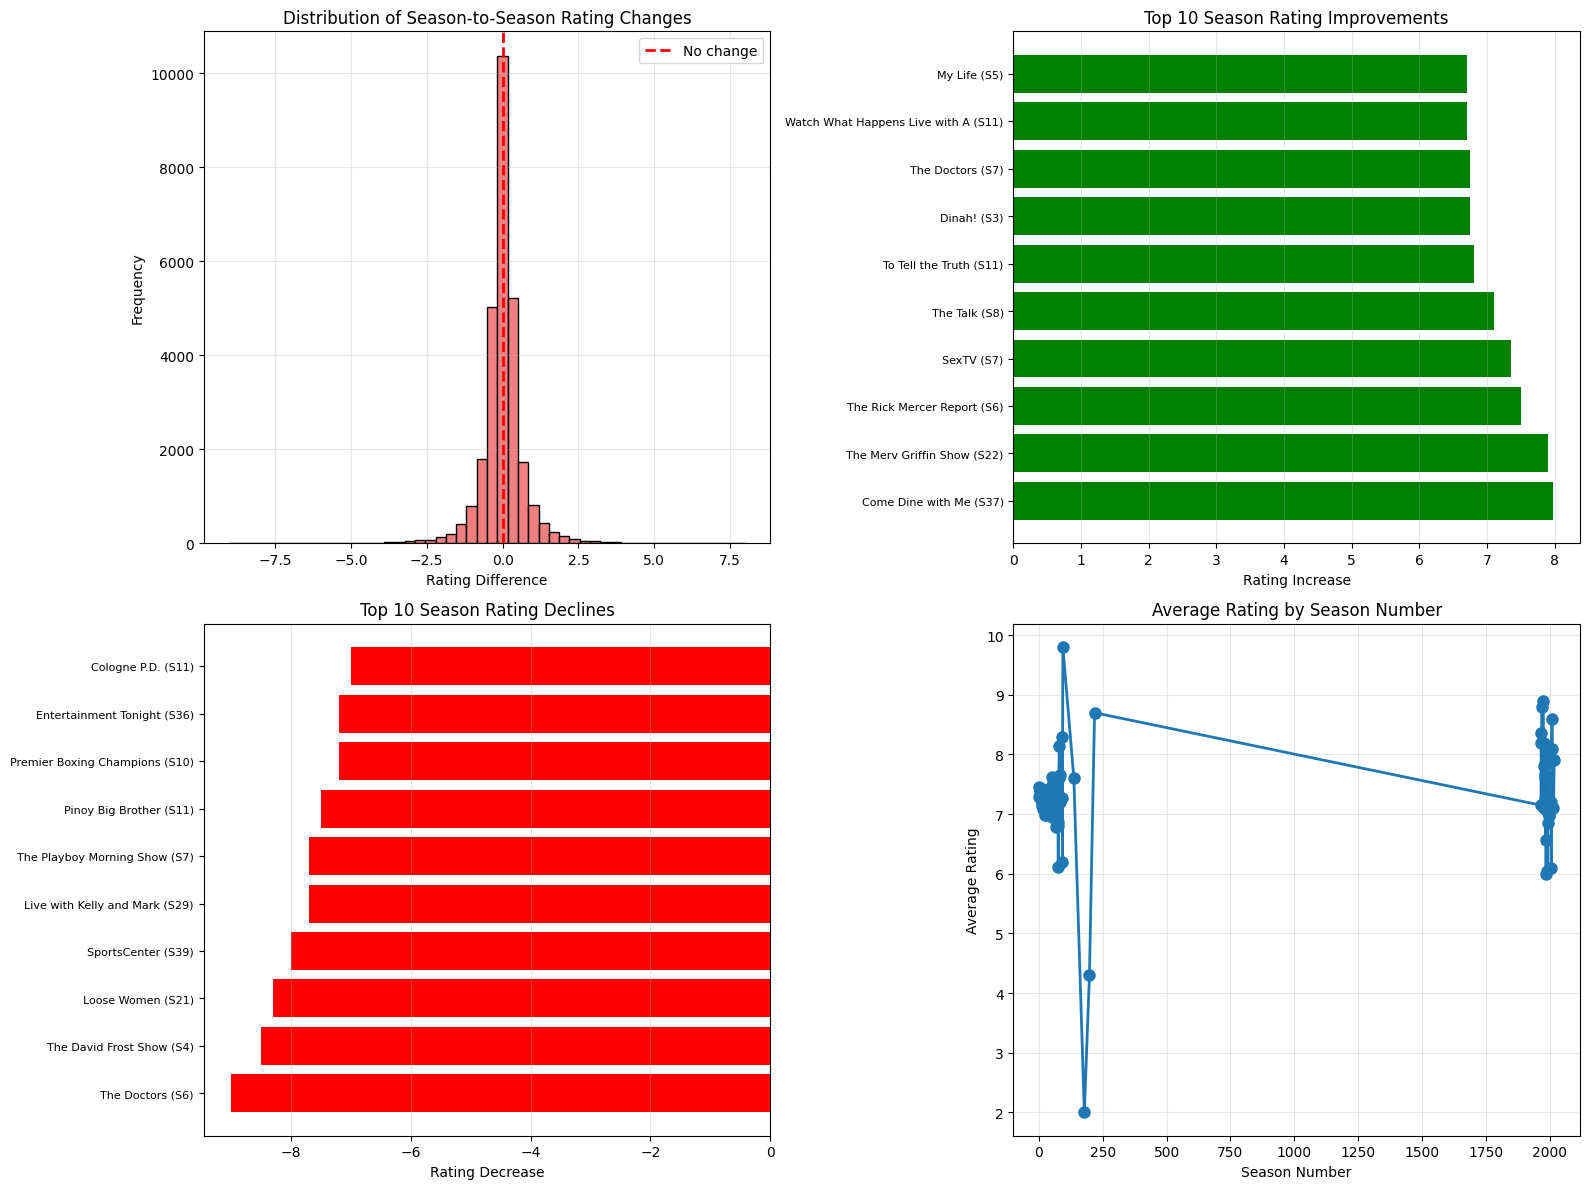

Total records: 33,003


Sample records: 9,943


+------------+------------+-----------------+----------+------------------+--------------------+---------+-----------------+
|parentTconst|seasonNumber|season_avg_rating|max_season|prev_season_rating|         rating_diff|   tconst|     primaryTitle|
+------------+------------+-----------------+----------+------------------+--------------------+---------+-----------------+
|   tt0042098|           2|              5.5|         5|              NULL|                NULL|tt0042098|           Danger|
|   tt0042168|           2|8.335000061988831|        18|  8.38888888888889|-0.05388882690005836|tt0042168|  What's My Line?|
|   tt0042168|          11| 8.03061225462933|        18| 7.961224517043756|  0.0693877375855747|tt0042168|  What's My Line?|
|   tt0042168|          13|7.628000040054321|        18| 7.632000093460083|-0.00400005340576...|tt0042168|  What's My Line?|
|   tt0044296|           2|6.200000047683716|         9| 6.324999928474426|-0.12499988079071045|tt0044296|This Is Your Life|


In [ ]:
# Get data from season_rating_diff analysis
print("Preparing Season Rating Difference data...")
season_data = season_rating_diff(dataframes, save_path="output", min_seasons=3)

# Sample data for faster training (adjust as needed)
sample_fraction = 0.3
season_data_sample = season_data.sample(False, sample_fraction, seed=42)

print(f"Total records: {season_data.count():,}")
print(f"Sample records: {season_data_sample.count():,}")
season_data_sample.show(5)

In [9]:
from pyspark.sql.functions import col, when
from pyspark.sql.types import DoubleType

# Feature engineering for Season Rating Diff
season_features = season_data_sample.select(
    col("seasonNumber").cast(DoubleType()).alias("seasonNumber"),
    col("season_avg_rating").cast(DoubleType()).alias("current_rating"),
    col("prev_season_rating").cast(DoubleType()).alias("prev_rating"),
    col("rating_diff").cast(DoubleType()).alias("label")
).na.drop()

# Create feature vector
feature_cols = ["seasonNumber", "current_rating", "prev_rating"]
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
season_features = assembler.transform(season_features)

# Split data
train_data, test_data = season_features.randomSplit([0.8, 0.2], seed=42)

print(f"Training set: {train_data.count():,} records")
print(f"Test set: {test_data.count():,} records")

Training set: 6,753 records


Test set: 1,673 records


In [10]:
# Train multiple regression models
print("Training regression models for Season Rating Difference...")

# 1. Linear Regression
lr = LinearRegression(featuresCol="features", labelCol="label", maxIter=10)
lr_model = lr.fit(train_data)
lr_predictions = lr_model.transform(test_data)

# 2. Random Forest with basic params
rf = RandomForestRegressor(featuresCol="features", labelCol="label", numTrees=20, maxDepth=5)
rf_model = rf.fit(train_data)
rf_predictions = rf_model.transform(test_data)

# 3. Gradient Boosted Trees
gbt = GBTRegressor(featuresCol="features", labelCol="label", maxIter=10, maxDepth=5)
gbt_model = gbt.fit(train_data)
gbt_predictions = gbt_model.transform(test_data)

print("Models trained successfully!")

Training regression models for Season Rating Difference...


25/12/03 10:28:05 WARN Instrumentation: [1bb16dac] regParam is zero, which might cause numerical instability and overfitting.
25/12/03 10:28:05 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
25/12/03 10:28:06 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


Models trained successfully!



Model Comparison:
                 Model         RMSE       R2          MAE
     Linear Regression 3.073495e-14 1.000000 1.865379e-14
         Random Forest 5.184631e-01 0.528081 3.562251e-01
Gradient Boosted Trees 3.167332e-01 0.849822 1.599971e-01


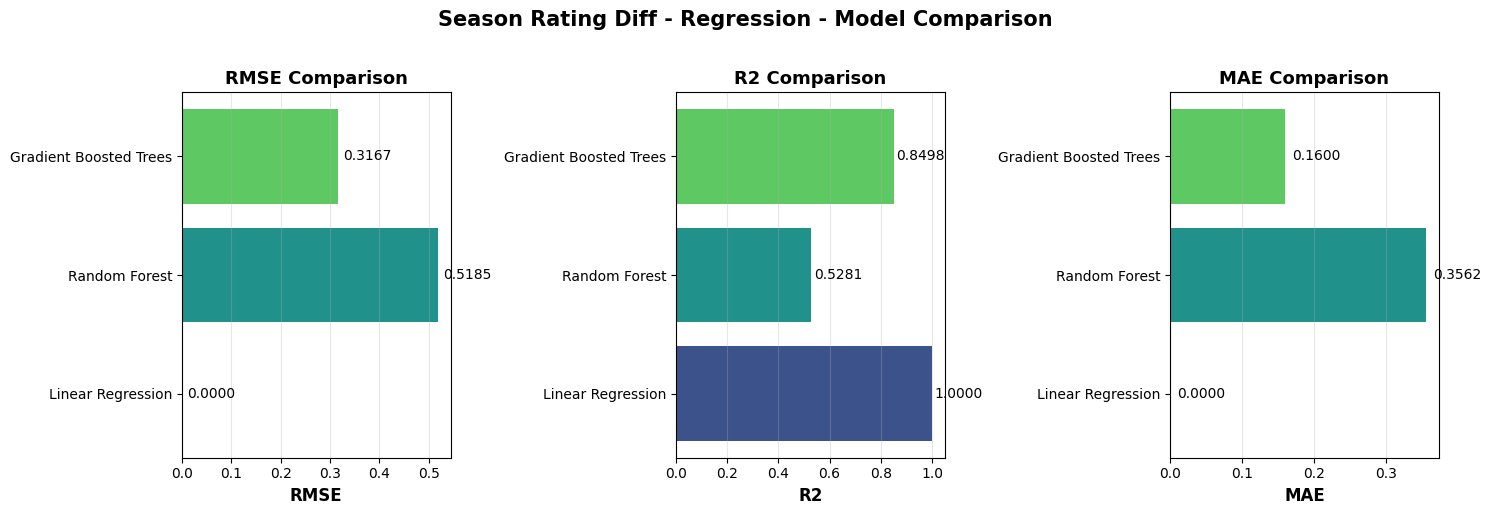

In [11]:
# Evaluate models
predictions_dict = {
    "Linear Regression": lr_predictions,
    "Random Forest": rf_predictions,
    "Gradient Boosted Trees": gbt_predictions
}

results = evaluate_regression_models(predictions_dict, label_col="label")
results_df = pd.DataFrame(results)
print("\nModel Comparison:")
print(results_df.to_string(index=False))

# Plot comparison
plot_model_comparison(results, "Season Rating Diff - Regression", save_path="output")

## 2. Regression Model: Genre Duration vs Rating

**Business Question:** Can we predict movie ratings based on genre and duration?

**Target Variable:** `averageRating`

**Features:** `runtimeMinutes`, genre features, year

Preparing Genre Duration Rating data...
Analyzing movies from 2000 to 2023


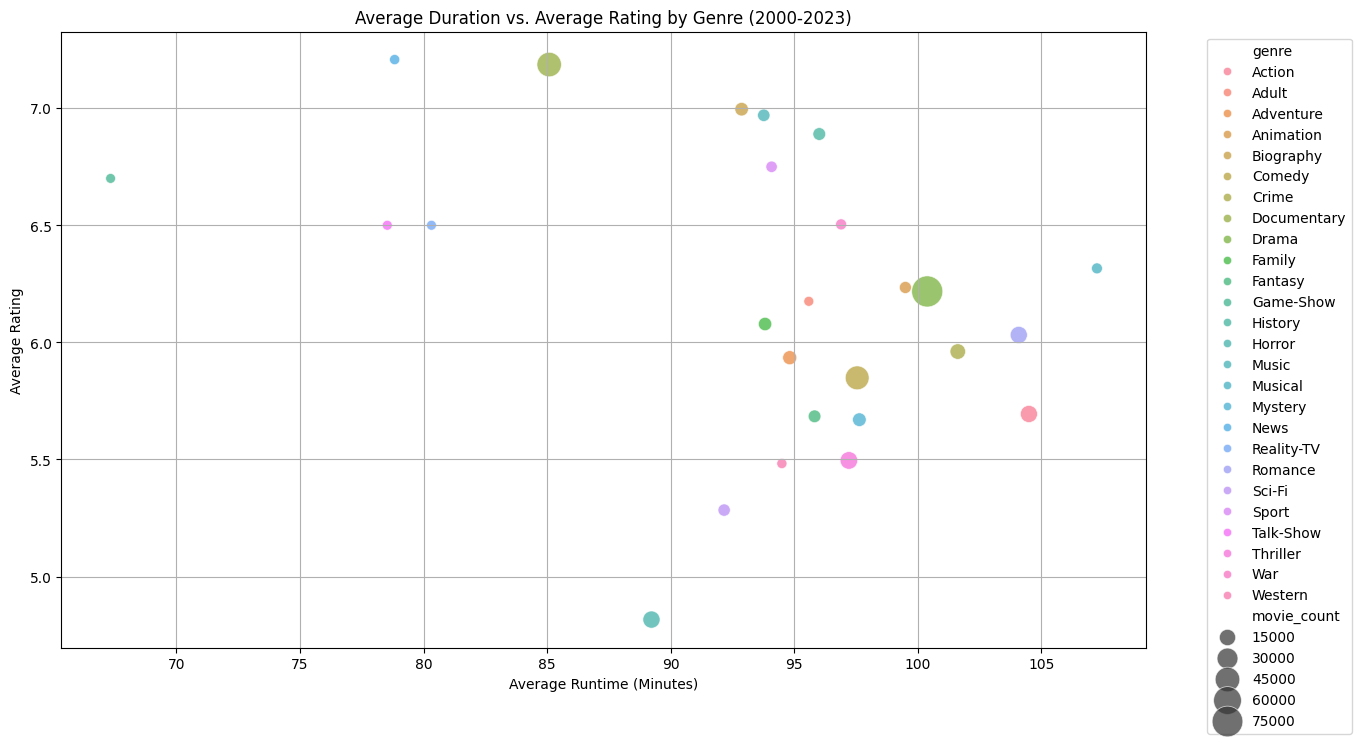

Sample records: 3


+-----------+-----------------+-----------------+-----------+
|      genre|      avg_runtime|       avg_rating|movie_count|
+-----------+-----------------+-----------------+-----------+
|Documentary|85.08503162333099|7.186229235546238|      44471|
|    Mystery|97.63993151586988|5.669849056327868|       7950|
| Reality-TV|            80.32| 6.49999999852828|         81|
+-----------+-----------------+-----------------+-----------+



In [14]:
# Get data from genre_duration_rating_analysis
print("Preparing Genre Duration Rating data...")
genre_data = genre_duration_rating_analysis(dataframes, save_path="output", year_range=(2000, 2023))

# Sample for faster training
genre_sample = genre_data.sample(False, 0.2, seed=42)
print(f"Sample records: {genre_sample.count():,}")
genre_sample.show(5)

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType
from pyspark.ml.feature import VectorAssembler

print("Preparing Genre Duration Rating data...")

# Використовуємо dataframes напряму
title_basics = dataframes["title.basics"]
title_ratings = dataframes["title.ratings"]

# Фільтруємо фільми та join з ratings
movies = title_basics.filter(
    (F.col("titleType") == "movie") &
    (F.col("runtimeMinutes").isNotNull()) &
    (F.col("startYear").isNotNull()) &
    (F.col("genres") != "\\N")
).select("tconst", "runtimeMinutes", "startYear", "genres")

genre_data = movies.join(title_ratings, "tconst", "inner").filter(
    (F.col("numVotes") >= 100) &  # Мінімум 100 голосів
    (F.col("startYear").cast("int") >= 2000)  # Тільки з 2000 року
)

# Sample for faster training
genre_sample = genre_data.sample(False, 0.2, seed=42)
print(f"Sample records: {genre_sample.count():,}")
genre_sample.show(5)

Preparing Genre Duration Rating data...


Sample records: 17,556


+---------+--------------+---------+--------------------+-------------+--------+
|   tconst|runtimeMinutes|startYear|              genres|averageRating|numVotes|
+---------+--------------+---------+--------------------+-------------+--------+
|tt0132245|           116|     2001|  Action,Drama,Sport|          4.6|   44765|
|tt0146063|            75|     2002|Adventure,Animati...|          6.3|     418|
|tt0151372|            78|     2000|         Documentary|          7.0|     387|
|tt0176185|            98|     2002|               Drama|          4.3|     349|
|tt0189960|           118|     2000|               Drama|          5.5|     109|
+---------+--------------+---------+--------------------+-------------+--------+
only showing top 5 rows


In [21]:
# Train models with hyperparameter tuning
print("Training with hyperparameter tuning...")

# Random Forest with GridSearch on smaller sample
rf = RandomForestRegressor(featuresCol="features", labelCol="label")

# Create parameter grid
paramGrid = ParamGridBuilder() \
    .addGrid(rf.numTrees, [10, 20]) \
    .addGrid(rf.maxDepth, [5, 10]) \
    .build()

# Use TrainValidationSplit for faster tuning
evaluator = RegressionEvaluator(labelCol="label", metricName="rmse")
tvs = TrainValidationSplit(
    estimator=rf,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    trainRatio=0.8
)

# Fit on small sample first
small_sample = train_data.sample(False, 0.3, seed=42)
print(f"Tuning on {small_sample.count():,} records...")
tvs_model = tvs.fit(small_sample)

# Get best model and train on full data
best_rf = tvs_model.bestModel
print(f"Best params: numTrees={best_rf.getNumTrees}, maxDepth={best_rf.getMaxDepth()}")

# Train final model with best params
final_rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="label",
    numTrees=best_rf.getNumTrees,
    maxDepth=best_rf.getMaxDepth()
)
final_model = final_rf.fit(train_data)
rf_predictions = final_model.transform(test_data)

# Also train baseline models
lr = LinearRegression(featuresCol="features", labelCol="label", maxIter=10)
lr_model = lr.fit(train_data)
lr_predictions = lr_model.transform(test_data)

print("Training complete!")

Training with hyperparameter tuning...


Tuning on 2,053 records...


Best params: numTrees=20, maxDepth=10


25/12/03 10:36:55 WARN Instrumentation: [c0450d0f] regParam is zero, which might cause numerical instability and overfitting.


Training complete!



Model Comparison:
                Model         RMSE       R2          MAE
    Linear Regression 1.019853e-13 1.000000 6.735067e-14
Random Forest (Tuned) 3.477325e-01 0.773534 2.151422e-01


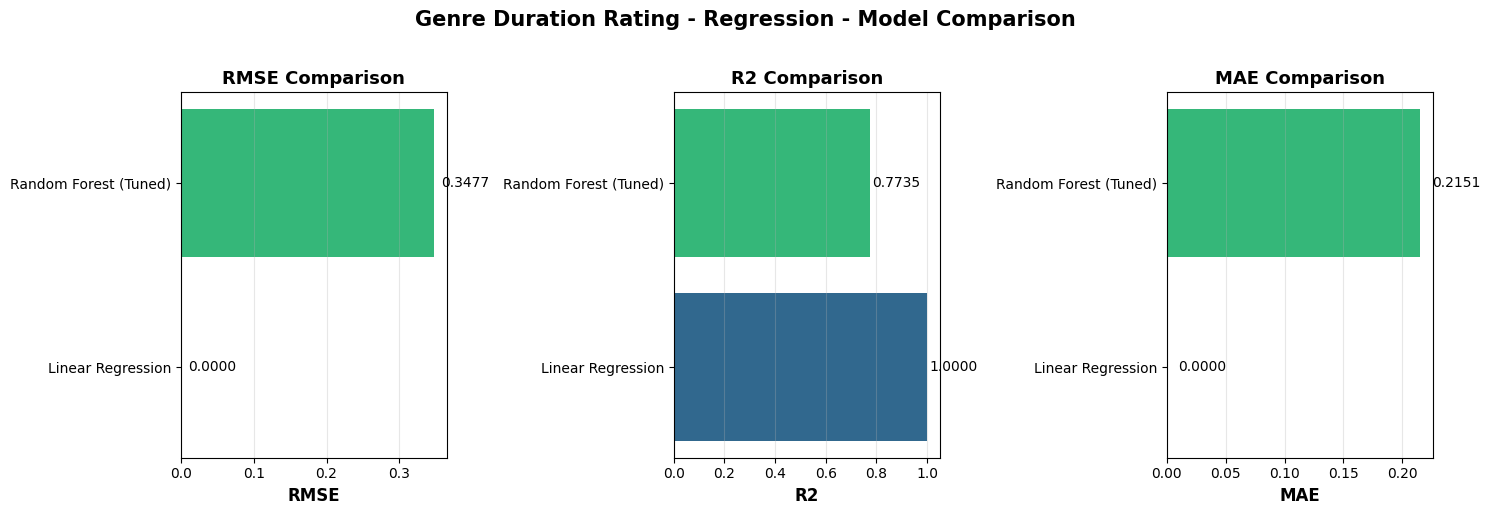

In [22]:
# Evaluate
predictions_dict = {
    "Linear Regression": lr_predictions,
    "Random Forest (Tuned)": rf_predictions
}

results = evaluate_regression_models(predictions_dict, label_col="label")
results_df = pd.DataFrame(results)
print("\nModel Comparison:")
print(results_df.to_string(index=False))

plot_model_comparison(results, "Genre Duration Rating - Regression", save_path="output")

## 6. Classification Model: Underrated Genre Combos

**Business Question:** Can we identify underrated genre combinations?

**Target Variable:** Multi-class (underrated / mainstream / niche)

**Features:** Genre combination, avg_rating, total_votes

Preparing Underrated Genre Combos data...


/app/analysis/genre_analysis.py:816: FutureWarning:                             

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


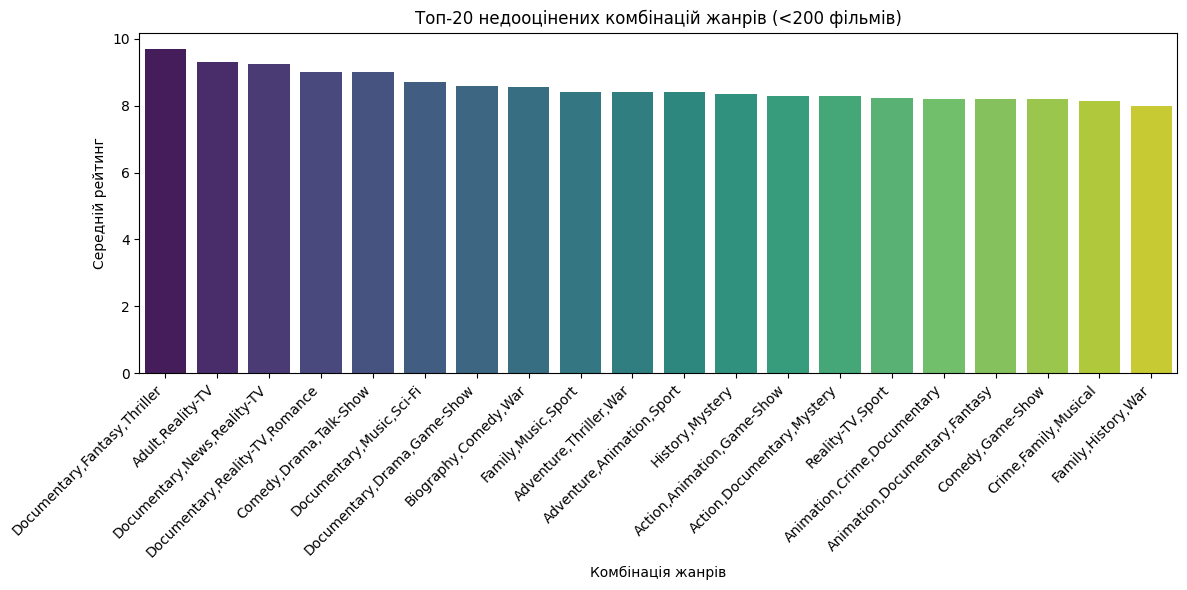

Total records: 1,090


+--------------------+-----------------+----------+
|       sorted_genres|       avg_rating|film_count|
+--------------------+-----------------+----------+
|Documentary,Fanta...|9.699999809265137|         1|
|    Adult,Reality-TV|9.300000190734863|         1|
|Documentary,News,...|             9.25|         2|
|Documentary,Reali...|              9.0|         1|
|Comedy,Drama,Talk...|              9.0|         1|
+--------------------+-----------------+----------+
only showing top 5 rows


In [6]:
# Get data
print("Preparing Underrated Genre Combos data...")
genre_combo_data = underrated_genre_combos(dataframes, save_path="output")

print(f"Total records: {genre_combo_data.count():,}")
genre_combo_data.show(5)

In [9]:
from pyspark.sql.functions import col, when
from pyspark.sql.types import DoubleType

# Feature engineering
# Create multi-class label based on rating and votes
genre_features = genre_combo_data.select(
    col("avg_rating").cast(DoubleType()).alias("avg_rating"),
    col("total_votes").cast(DoubleType()).alias("total_votes"),
    col("film_count").cast(DoubleType()).alias("film_count")
).na.drop()

# Create labels: 0=mainstream, 1=underrated, 2=niche
genre_features = genre_features.withColumn(
    "label",
    when((col("avg_rating") > 7.5) & (col("total_votes") < 10000), 1.0)  # underrated
    .when(col("total_votes") > 100000, 0.0)  # mainstream
    .otherwise(2.0)  # niche
)

# Assemble
feature_cols = ["avg_rating", "total_votes", "film_count"]
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
genre_features = assembler.transform(genre_features)

print("Class distribution:")
genre_features.groupBy("label").count().show()

train_data, test_data = genre_features.randomSplit([0.8, 0.2], seed=42)
print(f"Training: {train_data.count():,}, Test: {test_data.count():,}")

{"ts": "2025-12-03 11:04:01.023", "level": "ERROR", "logger": "DataFrameQueryContextLogger", "msg": "[UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `total_votes` cannot be resolved. Did you mean one of the following? [`film_count`, `sorted_genres`, `avg_rating`]. SQLSTATE: 42703", "context": {"file": "line 8 in cell [9]", "line": "", "fragment": "col", "errorClass": "UNRESOLVED_COLUMN.WITH_SUGGESTION"}, "exception": {"class": "Py4JJavaError", "msg": "An error occurred while calling o167.select.\n: org.apache.spark.sql.AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `total_votes` cannot be resolved. Did you mean one of the following? [`film_count`, `sorted_genres`, `avg_rating`]. SQLSTATE: 42703;\n'Project [cast(avg_rating#112 as double) AS avg_rating#182, cast('total_votes as double) AS total_votes#183, cast(film_count#113L as double) AS film_count#184]\n+- Sort [avg_rating#112 DESC NULL

AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `total_votes` cannot be resolved. Did you mean one of the following? [`film_count`, `sorted_genres`, `avg_rating`]. SQLSTATE: 42703;
'Project [cast(avg_rating#112 as double) AS avg_rating#182, cast('total_votes as double) AS total_votes#183, cast(film_count#113L as double) AS film_count#184]
+- Sort [avg_rating#112 DESC NULLS LAST], true
   +- Filter (film_count#113L < cast(200 as bigint))
      +- Aggregate [sorted_genres#109], [sorted_genres#109, avg(averageRating#37) AS avg_rating#112, count(tconst#14) AS film_count#113L]
         +- Project [tconst#14, genres#22, averageRating#37, numVotes#38, genre_count#108, concat_ws(,, array_sort(split(genres#22, ,, -1), lambdafunction(if ((isnull(lambda left#110) AND isnull(lambda right#111))) 0 else if (isnull(lambda left#110)) 1 else if (isnull(lambda right#111)) -1 else if ((lambda left#110 < lambda right#111)) -1 else if ((lambda left

In [ ]:
# Train multi-class classifiers
print("Training Genre Combo classifiers...")

lr = LogisticRegression(featuresCol="features", labelCol="label", maxIter=10)
lr_model = lr.fit(train_data)
lr_predictions = lr_model.transform(test_data)

rf = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=20, maxDepth=5)
rf_model = rf.fit(train_data)
rf_predictions = rf_model.transform(test_data)

# Evaluate with multiclass metrics
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

evaluator_acc = MulticlassClassificationEvaluator(labelCol="label", metricName="accuracy")
evaluator_f1 = MulticlassClassificationEvaluator(labelCol="label", metricName="f1")

results = []
for name, preds in [("Logistic Regression", lr_predictions), ("Random Forest", rf_predictions)]:
    acc = evaluator_acc.evaluate(preds)
    f1 = evaluator_f1.evaluate(preds)
    results.append({"Model": name, "Accuracy": acc, "F1": f1})

print("\nResults:")
print(pd.DataFrame(results).to_string(index=False))

plot_model_comparison(results, "Genre Combos - Classification", save_path="output")